In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import CIFAR10, CIFAR100, MNIST, STL10
import torchvision.transforms as T
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mhnlib.utils as mhn_utils
from math import log, sqrt
import seaborn as sns
from tqdm.auto import tqdm
from pathlib import Path
import re
from einops import rearrange
import pandas as pd
import networkx as nx
import glasbey
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
#device = torch.device("cpu")

In [ ]:
from numba import njit
@njit(nogil=True)
def distance_tree(data_list, threshold : float):
    edges_from = []
    edges_to = []
    num_levels = len(data_list)
    for level in range(0, num_levels-1):
        num_elements_level = len(data_list[level])
        num_elements_next_level = len(data_list[level+1])
        
        for idx in range(0, num_elements_level):
            sq_norm_i = np.sum(data_list[level][idx]**2)
            num_children_found = 0
            for jdx in range(0, num_elements_next_level):
                sq_norm_j = np.sum(data_list[level+1][jdx]**2)
                dist_ij = sq_norm_i + sq_norm_j - 2*np.sum(data_list[level][idx]*data_list[level+1][jdx])
                if dist_ij <= threshold:
                    edges_from.append((level, idx))
                    edges_to.append((level+1, jdx))
                    num_children_found += 1
    return np.array(edges_from), np.array(edges_to)

def disambiguate_fixed_points_local(x_fp_list, weights, thresholds):
    pbar = tqdm(range(len(x_fp_list)))
    num_fps = [ ]
    x_fps = []
    w_fps = []
    for idx in pbar:
        x_unique, x_unique_counts, labels = mhn_utils.group_by_distance(x_fp_list[idx], thresholds[idx])
        w_unique = torch.zeros(x_unique.shape[0], weights.shape[-1])
        w_unique.index_add_(0, labels, weights[idx])
        w_unique /= x_unique_counts[:, None]
        num_fps.append(x_unique.shape[0])
        x_fps.append(torch.as_tensor(x_unique))
        w_fps.append(w_unique)
        pbar.set_postfix({"Found clusters" : num_fps[-1] })
    num_fps = torch.as_tensor(num_fps)
    return x_fps, w_fps, num_fps


def disambiguate_fixed_points(x_fp_list, weights, threshold, non_decreasing):
    pbar = tqdm(range(len(x_fp_list)))
    num_fps = [ ]
    x_fps = []
    w_fps = []
    for idx in pbar:
        x_unique, x_unique_counts, labels = mhn_utils.group_by_distance(x_fp_list[idx], threshold)
        w_unique = torch.zeros(x_unique.shape[0], weights.shape[-1])
        w_unique.index_add_(0, labels, weights[idx])
        w_unique /= x_unique_counts[:, None]
        num_fps.append(x_unique.shape[0])
        x_fps.append(torch.as_tensor(x_unique))
        w_fps.append(w_unique)
        if len(num_fps) > 1 and non_decreasing:
            if num_fps[-1] < num_fps[-2]:
                raise Exception("No valid cluster possible.")
        pbar.set_postfix({"Found clusters" : num_fps[-1] })
    num_fps = torch.as_tensor(num_fps)
    return x_fps, w_fps, num_fps
def disambiguate_fixed_points_adaptive(x_fp_list, weights, thresholds):
    pbar = tqdm(range(len(x_fp_list)))
    num_fps = [ ]
    x_fps = []
    w_fps = []
    for idx in pbar:
        found_threshold = False
        for threshold in thresholds:
            x_unique, x_unique_counts, labels = mhn_utils.group_by_distance(x_fp_list[idx], threshold)
            pbar.set_description(f"Threshold : {threshold}. Num. found {len(x_unique)}")
            if (len(num_fps) >= 1 and len(x_unique) >= num_fps[-1]) or len(num_fps) == 0:
                found_threshold = True
                w_unique = torch.zeros(x_unique.shape[0], weights.shape[-1])
                w_unique.index_add_(0, labels, weights[idx])
                w_unique /= x_unique_counts[:, None]
                num_fps.append(x_unique.shape[0])
                x_fps.append(torch.as_tensor(x_unique))
                w_fps.append(w_unique)
            if found_threshold:
                break
        if not found_threshold:
            raise Exception("No valid cluster possible.")
        pbar.set_postfix({"Found clusters" : num_fps[-1] })
    num_fps = torch.as_tensor(num_fps)
    return x_fps, w_fps, num_fps

### Select data

In [ ]:
DATASET = "ema"
IS_IMAGE = DATASET in ["mnist", "stl10", "cifar10", "cifar100"]
data_path = Path("paper_results/experiments/")
quenched_files = list(data_path.glob(f"{DATASET}*weights_quenched*.pt"))
annealed_files = list(data_path.glob(f"{DATASET}*weights_annealed*.pt"))
file_df = {'is_quenched' : [], 'num_per_label' : [], 'noise' : [], 'is_euclidean' : [], 'is_centered' : [], 'file' : []}
for file in quenched_files + annealed_files:
    is_quenched = 'quenched' in file.stem
    num_per_label = re.search(r'per_label=(\d+)', file.stem)
    if num_per_label:
        num_per_label = int(num_per_label.group(1))
    else:
        num_per_label = np.nan
    is_euclidean = 'euclidean=True' in file.stem
    is_centered = 'centered=True' in file.stem
    logit_noise = re.search(r'noise=(\d+\.?\d*)', file.stem)
    if logit_noise:
        logit_noise = float(logit_noise.group(1))
    else:
        logit_noise = np.nan
    file_df['is_quenched'].append(is_quenched)
    file_df['num_per_label'].append(num_per_label)
    file_df['noise'].append(logit_noise)
    file_df['is_euclidean'].append(is_euclidean)
    file_df['is_centered'].append(is_centered)
    file_df['file'].append(str(file.absolute()))
file_df = pd.DataFrame.from_dict(file_df)

In [ ]:
is_centered = False
is_euclidean = True
sub_file_df = file_df[(file_df['is_euclidean'] == is_euclidean) & (file_df['is_centered'] == is_centered)]
logit_noise = 1.0
num_per_label = 5 if IS_IMAGE else None
if num_per_label is not None:
    quenched_file_mask = (file_df['is_euclidean'] == is_euclidean) & (file_df['is_centered'] == is_centered) & (file_df['is_quenched'] == True) & (file_df['num_per_label'] == num_per_label)
    annealed_file_mask = (file_df['is_euclidean'] == is_euclidean) & (file_df['is_centered'] == is_centered) & (file_df['is_quenched'] == False) & (file_df['num_per_label'] == num_per_label) & (file_df['noise'] == logit_noise)
else:
    quenched_file_mask = (file_df['is_euclidean'] == is_euclidean) & (file_df['is_centered'] == is_centered) & (file_df['is_quenched'] == True)
    annealed_file_mask = (file_df['is_euclidean'] == is_euclidean) & (file_df['is_centered'] == is_centered) & (file_df['is_quenched'] == False)  & (file_df['noise'] == logit_noise)

In [ ]:
quenched_file_name = file_df[quenched_file_mask]['file'].iloc[0]
quenched_data = torch.load(quenched_file_name)
quenched_weights = quenched_data['weights']
shift = quenched_data['shift']
rms = quenched_data['rms']
betas = quenched_data['betas']
biases = quenched_data['biases']
patterns = quenched_data['patterns']
gram = patterns @ patterns.T
quenched_x = quenched_weights @ patterns

In [ ]:
annealed_file_name = file_df[annealed_file_mask]['file'].iloc[0]
annealed_data = torch.load(annealed_file_name)
annealed_weights = annealed_data['weights']
annealed_x = annealed_weights @ patterns

In [ ]:
data_dict = torch.load(Path(quenched_file_name).parent / (f"{DATASET}_per_label={num_per_label}.pt" if IS_IMAGE else f"{DATASET}.pt"))
labels = data_dict['labels']
label_to_name = data_dict['label_to_name'] if 'label_to_name' in data_dict else None

### Extract unique fixed points (quenched)

In [ ]:
if not is_euclidean:
    quenched_thresholds = [1e-2,1e-3,1e-4]
    for quenched_threshold in quenched_thresholds:
        try:
            x_quenched_fps, w_quenched_fps, num_quenched_fps = disambiguate_fixed_points(quenched_x, quenched_weights, quenched_threshold, True)
            print(f"Proper clusters at {quenched_threshold}")
            break
        except:
            print(f"Threshold too small {quenched_threshold}")
else:
    x_quenched_fps, w_quenched_fps, num_quenched_fps = disambiguate_fixed_points_local(quenched_x, quenched_weights, 1/torch.sqrt(betas))

In [ ]:
def build_weighted_simplices(
    W: torch.Tensor,
    n: int,
):
    """
    Build all simplices from edges (r=2) up to simplex size r=n.

    W : [K, N]
        K clusters, N points.

    Returns
    -------
    out[r]["simplices"] : [M_r, r]
    out[r]["strengths"] : [M_r]

    strength(a1,...,ar) = max_i min_j W[aj, i]
    """

    if W.ndim != 2:
        raise ValueError("W must have shape [K, N]")

    K = W.shape[0]
    vertices = torch.arange(K, device=W.device)

    out = {}

    for r in range(2, n + 1):

        # Not enough clusters to form an r-simplex
        if r > K:
            break

        simplices = torch.combinations(vertices, r=r)

        strengths = (
            W[simplices]
            .amin(dim=1)    # min over clusters
            .amax(dim=1)    # max over points
        )

        out[r] = {
            "simplices": simplices,
            "strengths": strengths,
        }

    return out

In [132]:
from scipy.sparse import coo_matrix, csr_matrix
import math
max_order = 3
strength_multiplier = torch.logspace(-6,0,100)
frac_num_simplices = torch.zeros(len(betas), len(strength_multiplier), max_order-1)
edge_matrices = {}
for beta_idx in tqdm(range(len(betas))):
    w_fp = w_quenched_fps[beta_idx]
    found_simplices = build_weighted_simplices(w_fp, max_order)
    for order in range(2, max_order+1):
        if order not in found_simplices:
            break
        simplices = found_simplices[order]["simplices"]
        strengths = found_simplices[order]["strengths"]
        frac_num_simplices[beta_idx, :, order-2] = (strengths[:,None] >= strength_multiplier[None,:]).sum(dim=0)/ math.comb(w_fp.shape[0], order)
        if order == 2:
            edge_matrix = coo_matrix((strengths.cpu().numpy(), (simplices[:,0].cpu().numpy(), simplices[:,1].cpu().numpy())), shape=(w_fp.shape[0], w_fp.shape[0]))
            edge_matrix = (edge_matrix + edge_matrix.T)
            edge_matrices[beta_idx] = edge_matrix.tocsr()

  0%|          | 0/600 [00:00<?, ?it/s]

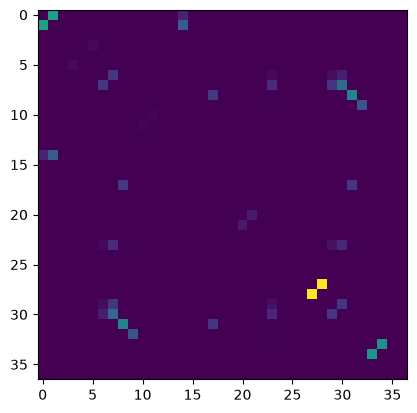

In [137]:
plt.imshow(np.log(1+edge_matrices[400].todense()))

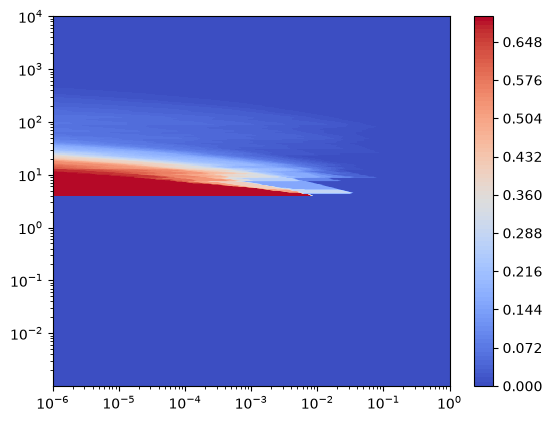

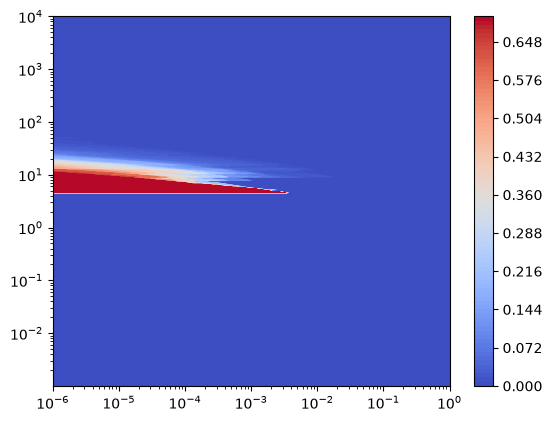

In [124]:
plt.contourf(strength_multiplier, betas, frac_num_simplices[:,:,0].log1p(), levels=100, cmap='coolwarm')
plt.colorbar()
plt.yscale('log')
plt.xscale('log')
plt.show()
plt.contourf(strength_multiplier, betas, frac_num_simplices[:,:,1].log1p(), levels=100, cmap='coolwarm')
plt.colorbar()
plt.yscale('log')
plt.xscale('log')
plt.show()

In [ ]:
tot_num_triples = torch.zeros(len(betas), len(strength_multiplier), dtype=torch.int32)
tot_num_edges = torch.zeros(len(betas), len(strength_multiplier), dtype=torch.int32)
for beta_idx in range(len(betas)):
    w_fp = w_quenched_fps[beta_idx]

    if len(w_fp) < 2:
        continue

    pairs = torch.combinations(torch.arange(w_fp.shape[0]), r=2)

    pair_strength = torch.minimum(
        w_fp[pairs[:, 0]],
        w_fp[pairs[:, 1]],
    ).max(dim=1).values

    num_edges = (pair_strength[None,...] >= strength_multiplier[:, None]/pair_strength.shape[0]).sum(dim=1)
    tot_num_edges[beta_idx, :] = num_edges

    if len(w_fp) < 3:
        continue

    triples = torch.combinations(torch.arange(w_fp.shape[0]), r=3)

    triple_strength = torch.minimum(
        torch.minimum(
            w_fp[triples[:, 0]],
            w_fp[triples[:, 1]],
        ),
        w_fp[triples[:, 2]],
    ).max(dim=1).values
    
    num_triples = (triple_strength[None,...] >= strength_multiplier[:, None]/triple_strength.shape[0]).sum(dim=1)
    tot_num_triples[beta_idx, :] = num_triples

In [ ]:
plt.contourf(strength_multiplier, betas, tot_num_edges)
plt.yscale('log')
plt.xscale('log')

In [ ]:
if IS_IMAGE:
    from diffusers import AutoencoderKL
    ae_model = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse")
    ae_model = ae_model.to(device).eval()
    ae_model.requires_grad_(False)
    ae_scaling = ae_model.config.scaling_factor
    
    source_data_file = Path(quenched_file_name).parent
    if num_per_label is not None or np.isfinite(num_per_label):
        source_data_file = source_data_file / f"{DATASET}_per_label={num_per_label}.pt"
    else:
        source_data_file = source_data_file / f"{DATASET}.pt"
    source_data = torch.load(source_data_file)
    source_latents = source_data['latents']
    C_latents, H_latents, W_latents = source_latents.shape[1:]

    image_quenched_fps = []
    for x in x_quenched_fps:
        torch.cuda.empty_cache()
        images = ae_model.decode((x*rms + shift).view(-1,C_latents, H_latents, W_latents).to(device)).sample.cpu()
        image_quenched_fps.append(images)

    #image_annealed_fps = []
    #for x in x_annealed_fps:
    #    torch.cuda.empty_cache()
    #    images = ae_model.decode(x.view(-1,C_latents, H_latents, W_latents).to(device)).sample.cpu()
    #    image_annealed_fps.append(images)
else:
    image_quenched_fps = None
    #image_annealed_fps = None

In [ ]:
#if image_annealed_fps is not None:
#    grayscale_conversion = torch.tensor([0.299, 0.587, 0.114])
#    jump_indices = torch.argwhere(torch.diff(num_annealed_fps) > 0).flatten()
#    for beta_idx in jump_indices:
#        images = image_annealed_fps[beta_idx]
#        fig, axs = plt.subplots(ncols=images.shape[0], figsize=(20,4))
#        if images.shape[0] == 1:
#            axs = [axs]
#        for idx in range(images.shape[0]):
#            axs[idx].imshow((1+(images[idx].permute(1,2,0) @ grayscale_conversion).clip(-1,1))/2)
#        plt.show()

### Class weights

In [ ]:
num_labels = len(torch.unique(labels))
w_quenched_per_label_fps = []
for w_fp in w_quenched_fps:
    w_per_label = torch.zeros(w_fp.shape[0], num_labels)
    w_per_label.index_add_(1, labels, w_fp)
    w_quenched_per_label_fps.append(w_per_label)
jump_indices = torch.argwhere(torch.diff(num_quenched_fps) > 0).flatten()+1
jump_indices = torch.cat([torch.zeros(1, dtype=jump_indices.dtype), jump_indices, (len(num_quenched_fps)-1)*torch.ones(1, dtype=jump_indices.dtype) ])

### PCA plots (quenched)

In [ ]:
fp_nodes = []
for beta_idx in range(len(x_quenched_fps)):
    for idx in range(len(x_quenched_fps[beta_idx])):
        fp_nodes.append((beta_idx, idx))
for cc_threshold in [1e-2]:
    
    edgelist_from, edgelist_to = distance_tree([x.numpy() for x in x_quenched_fps], cc_threshold)
    
    G = nx.Graph()
    G.add_nodes_from(fp_nodes)
    G.add_edges_from(
        zip(map(tuple, edgelist_from), map(tuple, edgelist_to))
    )
    
    fp_connected_components = list(nx.connected_components(G))
    
    num_fp_cc = len(fp_connected_components)
    fp_tags = {}
    for cc_index, cc_ in enumerate(fp_connected_components):
        cc = np.array(list(cc_))
        cc = cc[np.argsort(cc[:,0])]
        for el in cc:
            fp_tags[(el[0].item(),el[1].item())] = cc_index
    fp_tag_colors = np.array([
        mcolors.to_rgb(c)
        for c in glasbey.create_palette(palette_size=num_fp_cc)
    ])
    print(f"Number of connected components: {num_fp_cc}")

In [ ]:
pca_patterns = PCA(n_components=5).fit(patterns)
patterns_proj = pca_patterns.transform(patterns)
grayscale_conversion = torch.tensor([0.299, 0.587, 0.114])
jump_indices = torch.argwhere(torch.diff(num_quenched_fps) > 0).flatten()+1
jump_indices = torch.cat([torch.zeros(1, dtype=jump_indices.dtype), jump_indices, (len(num_quenched_fps)-1)*torch.ones(1, dtype=jump_indices.dtype) ])
sequences_save_dir = Path(f"paper_results/plots/{DATASET}/sequences_num_per_label={num_per_label}_centered={is_centered}_euclidean={is_euclidean}/")
sequences_save_dir.mkdir(parents=True, exist_ok=True)
for beta_idx in jump_indices:
    x_fp = x_quenched_fps[beta_idx]
    x_fp_proj = torch.as_tensor(pca_patterns.transform(x_fp))
    closest_fp_idx = ((patterns[:,None,:] - x_fp[None,:,:])**2).sum(dim=-1).argmin(dim=1)
    tags_fp = torch.as_tensor([ fp_tags[(beta_idx.item(),idx)] for idx in range(len(x_fp))]) 
    tags_patterns = torch.as_tensor([ fp_tags[(beta_idx.item(),idx.item())] for idx in closest_fp_idx])
    fig, axs = plt.subplots(ncols=2, figsize=(8,3))
    axs[0].scatter(patterns_proj[:,0], patterns_proj[:,1],color=fp_tag_colors[tags_patterns], alpha=0.3)
    axs[0].scatter(x_fp_proj[:,0], x_fp_proj[:,1], color=fp_tag_colors[tags_fp], marker='s', s=50, edgecolors='black')
    axs[0].set_xlabel("PCA #1")
    axs[0].set_ylabel("PCA #2")
    for fp_idx in range(len(x_fp_proj)):
        axs[0].text(x_fp_proj[fp_idx,0], x_fp_proj[fp_idx,1], f"{tags_fp[fp_idx]}", fontsize=15 )
    axs[1].scatter(patterns_proj[:,2], patterns_proj[:,3],color=fp_tag_colors[tags_patterns], alpha=0.3)
    axs[1].scatter(x_fp_proj[:,2], x_fp_proj[:,3], color=fp_tag_colors[tags_fp], marker='s', s=50, edgecolors='black')
    for fp_idx in range(len(x_fp_proj)):
        axs[1].text(x_fp_proj[fp_idx,2], x_fp_proj[fp_idx,3], f"{tags_fp[fp_idx]}", fontsize=15 )
    axs[1].set_xlabel("PCA #3")
    axs[1].set_ylabel("PCA #4")
    axs[0].set_aspect('equal')
    axs[1].set_aspect('equal')
    fig.suptitle(f"$\\beta={betas[beta_idx]:.2f}$")
    plt.savefig(sequences_save_dir / f"pca_quenched_beta_idx={beta_idx}.pdf", bbox_inches='tight')
    plt.close()
    if IS_IMAGE:
        images = image_quenched_fps[beta_idx]
        num_images = images.shape[0]
        fig, axs = plt.subplots(ncols=images.shape[0], figsize=(4*images.shape[0],4))
        if images.shape[0] == 1:
            axs = [axs]
        for idx in range(images.shape[0]):
            if DATASET == "mnist":
                axs[idx].imshow((1+(images[idx].permute(1,2,0) @ grayscale_conversion).clip(-1,1))/2, vmin=0, vmax=1, cmap='gray')
            else:
                axs[idx].imshow((1+images[idx].permute(1,2,0).clip(-1,1))/2, vmin=0, vmax=1, cmap='gray')
            axs[idx].set_title(fp_tags[(beta_idx.item(),idx)])
        plt.savefig(sequences_save_dir / f"images_quenched_beta_idx={beta_idx}.pdf", bbox_inches='tight')
        plt.close()

In [ ]:
from scipy.spatial import KDTree
stab_matr = mhn_utils.get_dual_symmetric_stability_matrix(patterns @ patterns.T, torch.ones(patterns.shape[0])/patterns.shape[0], False)
beta_ev = 1.0 / torch.linalg.eigvalsh(torch.cov(patterns.T))[-1]
beta_c = 1.0 / torch.linalg.eigvalsh(stab_matr)[-1]
beta_sigma = 1.0 / torch.var(patterns, dim=0).mean()
beta_max = 1.0 / torch.norm(patterns - patterns.mean(dim=0, keepdim=True), dim=1).max()**2
beta_nn = KDTree(patterns).query(patterns, k=2)[0][:, 1].mean()**-2
fig, ax = plt.subplots(figsize=(6, 4))
quenched_entropy = mhn_utils.get_entropy(quenched_weights).mean(dim=1)
ax.plot(betas, quenched_entropy/log(patterns.shape[0]))    
ax.scatter(betas[jump_indices], quenched_entropy[ jump_indices]/log(patterns.shape[0]), color='red', s=20, label='plotted', marker='x')
ax.axvline(x=beta_c, color='black', linestyle='--', label='$\\beta_c$')
ax.axvline(x=beta_sigma, color='red', linestyle='--', label='$\\beta_\\sigma$')
ax.axvline(x=beta_max, color='blue', linestyle='--', label='$\\beta_{\\rm{max \\, norm}}$')
ax.axvline(x=beta_nn, color='green', linestyle='--', label='$\\beta_{\\rm{nn}}$')
#ax.axvline(x=beta_ev, color='orange', linestyle='--', label='$\\beta_{ev}$')
plt.legend()
ax.set_xlabel('$\\beta$')
ax.set_ylabel('$H(w)/\\log{K}$')
plt.xscale('log')
plt.savefig(f"paper_results/plots/{DATASET}_weights_quenched_num_per_label={num_per_label}_centered={is_centered}_euclidean={is_euclidean}_entropy.pdf", bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns
gram_min = torch.min(gram)
gram_max = torch.max(gram)
dist_matrix = torch.cdist(patterns, patterns, p=2)
dist_min = torch.min(dist_matrix)
dist_max = torch.max(dist_matrix)
#cov_patterns = torch.cov(patterns.T)
#cov_vals = torch.linalg.eigvalsh(cov_patterns)
#hist_cum, edges_cum = torch.histogram(cov_vals, bins=100, density=True)
#hist_cum = torch.cumsum(hist_cum*torch.diff(edges_cum), dim=0)
matrices_save_dir = Path(f"paper_results/plots/{DATASET}/matrices_num_per_label={num_per_label}_centered={is_centered}_euclidean={is_euclidean}/")
matrices_save_dir.mkdir(parents=True, exist_ok=True)
for beta_idx in jump_indices:
    x_fp = x_quenched_fps[beta_idx]
    A =  patterns @ torch.linalg.pinv(x_fp)
    patterns_fitted = A @ x_fp
    gram_fitted = patterns_fitted @ patterns_fitted.T
    dist_matrix_fitted = torch.cdist(patterns_fitted, patterns_fitted, p=2)
    
    
    #if len(x_fp) > 1:
    #    cov_fp = torch.cov(x_fp.T)
    #    cov_vals_fp = torch.linalg.eigvalsh(cov_fp)
    #    hist_fp_cum, edges_fp_cum = torch.histogram(cov_vals_fp, bins=100, density=True)
    #    hist_fp_cum = torch.cumsum(hist_fp_cum*torch.diff(edges_fp_cum), dim=0)
    #    plt.plot(edges_cum[:-1].numpy(), hist_cum.numpy(), label='Patterns', color='blue')
    #    plt.plot(edges_fp_cum[:-1].numpy(), hist_fp_cum.numpy(), label='Fixed Points', color='orange')
    #    #plt.plot(np.sort(cov_vals.numpy()), np.linspace(0, 1, len(cov_vals)), label='Patterns', color='blue')
    #    #plt.plot(np.sort(cov_vals_fp.numpy()), np.linspace(0, 1, len(cov_vals_fp)), label='Fixed Points', color='orange')
    #    plt.xlabel("Eigenvalue")
    #    plt.ylabel("Count")
    #    plt.title(f"Covariance Eigenvalue Distribution at $\\beta={betas[beta_idx]:.2f}$")
    #    plt.legend()
    #    plt.show()
    fig, axs = plt.subplots(ncols=5, figsize=(24,4))
    axs[0].imshow(gram_fitted, vmin=gram_min, vmax=gram_max, cmap='bwr')
    axs[0].set_xlabel("Pattern Index")
    axs[0].set_ylabel("Pattern Index")
    axs[0].set_title("Fitted Patterns Gram Matrix")
    axs[1].imshow(gram, vmin=gram_min, vmax=gram_max, cmap='bwr')
    axs[1].set_xlabel("Pattern Index")
    axs[1].set_ylabel("Pattern Index")
    axs[1].set_title("Patterns Gram Matrix")
    axs[2].imshow(x_fp @ x_fp.T, vmin=gram_min, vmax=gram_max, cmap='bwr')
    axs[2].set_xlabel("Fixed Point Index")
    axs[2].set_ylabel("Fixed Point Index")
    axs[2].set_title("Fixed Points Gram Matrix")
    axs[3].imshow(dist_matrix_fitted, vmin=dist_min, vmax=dist_max, cmap='viridis')
    axs[3].set_xlabel("Pattern Index")
    axs[3].set_ylabel("Pattern Index")
    axs[3].set_title("Fitted Patterns Distance Matrix")
    axs[4].imshow(dist_matrix, vmin=dist_min, vmax=dist_max, cmap='viridis')
    axs[4].set_xlabel("Pattern Index")
    axs[4].set_ylabel("Pattern Index")
    axs[4].set_title("Patterns Distance Matrix")
    for ax in axs:
        fig.colorbar(ax.images[0], ax=ax, use_gridspec=True, location='right', shrink=0.8)
    plt.savefig(matrices_save_dir / f"beta_idx={beta_idx}.pdf", bbox_inches='tight')
    plt.close()

### Experiments

In [ ]:
def renormalization_step(x, betas = None, device = None, num_steps = 1000):
    from scipy.spatial import KDTree
    anchors  =  torch.as_tensor(x, dtype=torch.float32, device='cpu')
    if device is None:
        device = x.device
    if betas is None:
        anchors_tree = KDTree(anchors)
        lengthscale_min = 0.1*anchors_tree.query(anchors, k=2)[0][:, 1].mean()
        lengthscale_max = 10.0*torch.std(anchors, dim=0).mean() 
        betas = torch.linspace(1/(lengthscale_max**2), 1/(lengthscale_min**2), 1000).to(device)
    else:
        betas = torch.as_tensor(betas, dtype=torch.float32, device=device)
    anchors = anchors.to(device)
    x = torch.clone(anchors).to(device)
    biases = -0.5*(anchors.pow(2)).sum(dim=-1)

    x, weights = mhn_utils.deterministic_dynamics(anchors, biases, betas, x, num_iterations=num_steps, return_probs = True)
    x = x.squeeze(1)
    weights = weights.squeeze(1)
    anchors = anchors.detach().cpu()
    x= x.detach().cpu()
    weights = weights.detach().cpu()
    biases = biases.detach().cpu()
    betas = betas.detach().cpu()

    full_entropies = mhn_utils.get_entropy(weights)

    from math import sqrt, log
    x_fps = []
    w_fps = []
    entropies = []
    entropy_gaps = []
    for beta_idx in range(x.shape[0]):
        x_fp = mhn_utils.group_by_distance(x[beta_idx], eps=1/sqrt(betas[beta_idx].cpu().item()))[0]
        logits = x_fp @ anchors.T
        logits += biases
        logits *= betas[beta_idx].view(-1, 1)
        w_fp = torch.softmax(logits, dim=-1)
        entropies.append(mhn_utils.get_entropy(w_fp))
        entropy_gaps.append(entropies[-1].max() - entropies[-1].min())
        w_fps.append(w_fp)
        x_fps.append(x_fp)
    entropy_gaps = torch.as_tensor(entropy_gaps)
    beta_opt_idx = torch.argmax(entropy_gaps).item()
    beta_opt_idx = torch.argmax(full_entropies.max(dim=1).values - full_entropies.min(dim=1).values).item()
    #beta_opt_idx = torch.argmax(entropies.max(dim=1).values - entropies.min(dim=1).values).item()
    return x_fps[beta_opt_idx], w_fps[beta_opt_idx], beta_opt_idx, betas, entropy_gaps

In [ ]:
test_patterns = []
num_per_center = 10
sigma_test = 0.1
for idx in range(20):
    center = torch.randn(2)
    test_patterns.append(center + torch.randn((num_per_center, 2)) * sigma_test)
test_patterns = torch.cat(test_patterns, dim=0)

In [ ]:
patterns_renorm = torch.clone(patterns)
patterns_renorm -= patterns_renorm.mean(dim=0, keepdim=True)
patterns_renorm /= torch.linalg.norm(patterns_renorm, dim=1, keepdim=True).mean()
patterns_renorm_og = torch.clone(patterns_renorm)
betas_renorm = None
for step in range(10): 
    x_renorm, w_renorm, beta_opt_idx, betas_renorm, entropy_gaps = renormalization_step(patterns_renorm, betas=betas_renorm, num_steps=10000, device='cuda')
    print(f"Step {step}. Beta optimal index: {beta_opt_idx}. Beta value: {betas_renorm[beta_opt_idx]:.4f}")
    
    patterns_renorm = x_renorm
    
    plt.scatter(patterns_renorm_og[:,0], patterns_renorm_og[:,1], alpha=0.5)
    plt.scatter(patterns_renorm[:,0], patterns_renorm[:,1])
    plt.show()
    #plt.plot(betas_renorm, entropy_gaps, marker='o')
    #plt.show()
    print(patterns_renorm.shape[0])
    if beta_opt_idx == 0:
        break

In [ ]:
patterns_renorm = torch.clone(patterns)
for step in range(20):
    patterns_renorm, weights_renorm, beta_opt_idx,   _ = renormalization_step(patterns_renorm, betas = betas, device='cuda', num_steps = 20000)
    
    latents_renorm = (patterns_renorm*rms + shift).view(-1,C_latents, H_latents, W_latents)
    images_renorm = ((1+ae_model.decode(latents_renorm.to(device)).sample.cpu().clamp(-1,1))/2).cpu()
    fig, axs = plt.subplots(ncols=images_renorm.shape[0], figsize=(4*images_renorm.shape[0],4))
    if images_renorm.shape[0] == 1:
        axs = [axs]
    for idx in range(images_renorm.shape[0]):
        axs[idx].imshow(images_renorm[idx].permute(1,2,0).clip(0,1))
    fig.suptitle(f"Step {step}, Beta {betas[beta_opt_idx]:.2f}, Index {beta_opt_idx} out of {len(betas)}")
    plt.show()
    if patterns_renorm.shape[0] == 1:
        break